In [1]:
# import key libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForCausalLM

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Import GPT2-small and HPT2-Large models
tokenizer = AutoTokenizer.from_pretrained("gpt2")

gptSmall = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
gptLarge = AutoModelForCausalLM.from_pretrained("gpt2-large").to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [12]:
# the text
text = 'The goal of a correlation analysis is to compute a correlation coefficient. This coefficient is indicated using r, and is a number that encodes the normalized strength of the linear relationship between two variables. The normalization imposes boundaries of -1 to +1. Negative, zero, and positive correlation coefficients have distinct interpretations.'
tokens = tokenizer.encode(text,return_tensors='pt')
len(tokens[0])

62

In [5]:
# Forward pass the text through the GPT models

# GPT-2 small model
gptSmall.eval()
with torch.no_grad():
    gptSmall_output = gptSmall(tokens.to(device))

# GPT-2 large model
gptLarge.eval()
with torch.no_grad():
    gptLarge_output = gptLarge(tokens.to(device))



In [25]:
# For each token convert the logits for previous token to log softmax and get the coresponding value for the current token

sm_outputs = np.zeros((2,len(tokens[0])))
for i in range(1,len(tokens[0])):

  # Get the log-softmax for all dimensions of ith token

  # for GPT2-small model output
  lsm = F.log_softmax(gptSmall_output.logits[0,i-1,:], dim=-1)
  sm_outputs[0,i] = lsm[tokens[0,i]].item()

  # for GPT2-large model output
  lsm = F.log_softmax(gptLarge_output.logits[0,i-1,:], dim=-1)
  sm_outputs[1,i] = lsm[tokens[0,i]].item()


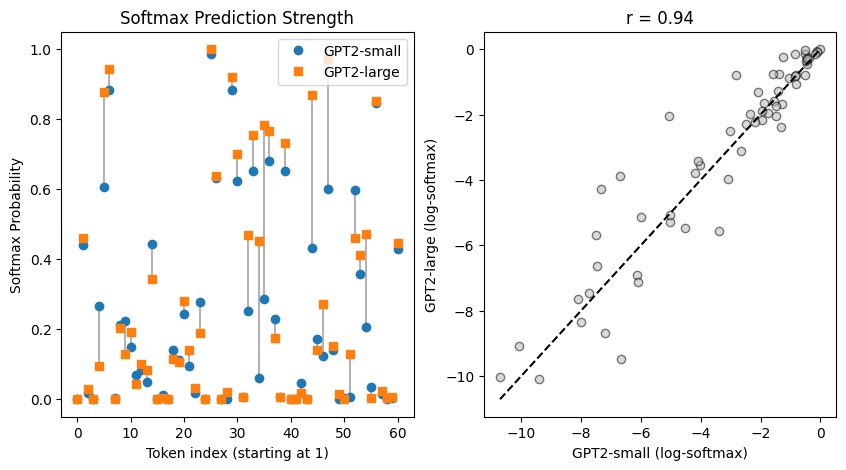

In [35]:
# Visualize the results
_, axs = plt.subplots(1,2,figsize=(10,5))

x = sm_outputs[0, 1:]
y = sm_outputs[1, 1:]

# prob plot
axs[0].cla()
axs[0].plot(np.exp(x), 'o', label='GPT2-small')
axs[0].plot(np.exp(y), 's', label='GPT2-large')
for i in range(len(x)):
    axs[0].plot([i, i], [np.exp(x[i]), np.exp(y[i])], color=[.7,.7,.7], zorder=-10)
axs[0].set(xlabel='Token index (starting at 1)', ylabel='Softmax Probability', title='Softmax Prediction Strength')
axs[0].legend()

# correlation + scatter
R = np.corrcoef(x, y)
axs[1].cla()
axs[1].plot(x, y, 'ko', markerfacecolor=[.7,.7,.7], alpha=.5, markeredgecolor='k')
mn, mx = min(x.min(), y.min()), max(x.max(), y.max())
axs[1].plot([mn, mx], [mn, mx], 'k--')
axs[1].set(xlabel='GPT2-small (log-softmax)', ylabel='GPT2-large (log-softmax)', title=f'r = {R[0,1]:.2f}')

plt.show()

# Create heatmap of the text based on the predictions

In [36]:
fig,ax = plt.subplots(figsize=(10,2))

# draw a text object
temp_text = ax.text(x=0,y=0,s='n',fontsize=12,fontfamily='monospace')

# get its bounding box in display coordinates
bbox = temp_text.get_window_extent(renderer=fig.canvas.get_renderer())

# convert from display to axis coordinates
inv = ax.transAxes.inverted()
bbox_axes = inv.transform([[bbox.x0,bbox.y0], [bbox.x1,bbox.y1]])
en_width = bbox_axes[1,0] - bbox_axes[0,0] # bbox is [(x0,y0),(x1,y1)]

plt.close(fig)

In [37]:
sm_outputs.shape

(2, 62)

In [50]:
# get the lengths of the words and convert to numpy
logsm_scale = np.zeros_like(sm_outputs)

# min/max scale
for i in range(sm_outputs.shape[0]):
  y = sm_outputs[i,1:]
  logsm_scale[i,1:] = (y - y.min()) / (y.max() - y.min())

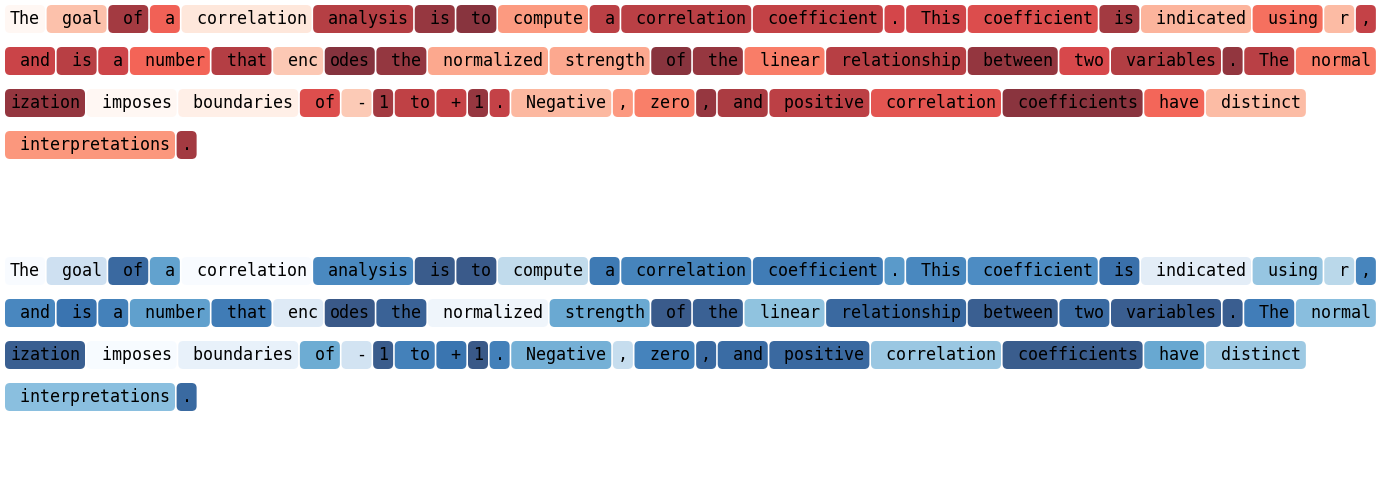

In [56]:
tokCount = 0

x_pos = 0  # starting x position (in axis coordinates)
y_pos = 1  # vertical center

fig, axs = plt.subplots(2,1,figsize=(10,6))
axs[0].axis('off')
axs[1].axis('off')


for toki in range(len(tokens[0])):

  # text of the token
  toktext = tokenizer.decode(tokens[0,toki])

  # width of the token
  token_width = en_width*len(toktext)

  # text object with background color matching the "activation"
  axs[0].text(x_pos+token_width/2, y_pos, toktext, fontsize=12, ha='center', va='center',fontfamily='monospace',
          bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Reds(logsm_scale[0,toki]), edgecolor='none', alpha=.8))

  axs[1].text(x_pos+token_width/2, y_pos, toktext, fontsize=12, ha='center', va='center',fontfamily='monospace',
          bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Blues(logsm_scale[1,toki]), edgecolor='none', alpha=.8))

  # update the word counter and x_pos
  tokCount += 1
  x_pos += token_width + .015 # plus a small gap

  # end of the line; reset coordinates and counter
  if tokCount>=20:
    y_pos -= .2
    x_pos = 0
    tokCount = 0

plt.show()